                       Time ID  demand_MWh  supply_MWh  solar_MWh   wind_MWh  \
0 2012-01-01 00:00:00+00:00  1     75.6549    9.150821        0.0  18.301642   
1 2012-01-01 00:00:00+00:00  2    557.8868    6.196411        0.0  12.392822   
2 2012-01-01 00:00:00+00:00  3     15.5237    6.855084        0.0  13.710167   
3 2012-01-01 00:00:00+00:00  4      8.6425    7.824092        0.0  15.648183   
4 2012-01-01 00:00:00+00:00  5     85.3649    2.053690        0.0   4.107380   

   solar_rel_prod  wind_rel_prod   latitude  longitude country  \
0             0.0         0.0284  42.094674  -8.113982     POR   
1             0.0         0.0103  41.587435  -8.326462     POR   
2             0.0         0.0283  41.585994  -6.722728     POR   
3             0.0         0.0408  41.597684  -6.342848     POR   
4             0.0         0.0092  41.373957  -7.350949     POR   

   solar_layout_MW  wind_layout_MW  
0         982.8607        644.4240  
1        1361.0601       1203.1866  
2         7

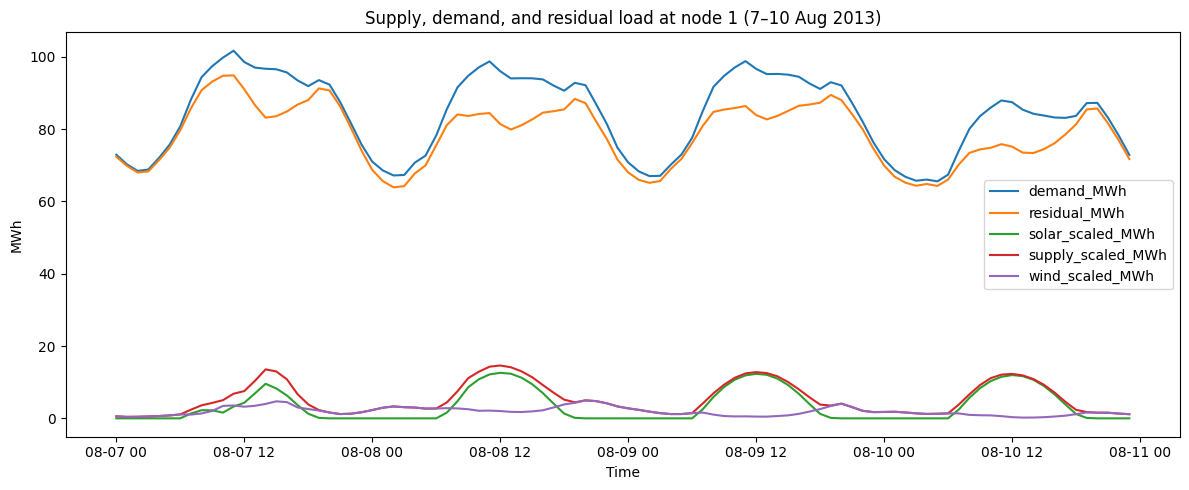

In [42]:
# %% Import the libraries we need
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Optional: inspect the first rows
print(dataset.head())


# ----------------------------------------------
# 2. Choose penetration/scaling for solar + wind
# ----------------------------------------------
# These scale the already-computed solar_MWh and wind_MWh columns
a_s = 0.01  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05  # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "ID",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

# Optional: inspect the result
print(dataset_residual.head())

# %% ---------------------------------------------------------
# 3. Filter to one node and to the dates 7-10 August 2013
# ---------------------------------------------------------
# Important: ID is stored as a string
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")

# %%
mask = (
    (subset_station["Time"].dt.year == 2013)
    & (subset_station["Time"].dt.month == 8)
    & (subset_station["Time"].dt.day.isin([7, 8, 9, 10]))
)

subset_data = subset_station.loc[mask].melt(
    id_vars="Time",
    var_name="source",
    value_name="MWh",
)

# Optional: inspect filtered long-format data
print(subset_data.head())


# -------------------------------
# 4. Plot the selected time series
# -------------------------------
plt.figure(figsize=(12, 5))

for source, group in subset_data.groupby("source"):
    plt.plot(group["Time"], group["MWh"], label=source)

plt.xlabel("Time")
plt.ylabel("MWh")
plt.title("Supply, demand, and residual load at node 1 (7–10 Aug 2013)")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
dataset.head()

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544


In [44]:
# 1. Add the data in  
dataset["date"] = dataset["Time"].dt.date





In [ ]:
daily_df = dataset.groupby(by=["ID","date"],as_index=False
).agg(
    {
    "solar_MWh":"sum",
    "wind_MWh":"sum",
    "country":"first",
    "latitude":"first",
    "longitude":"first"

    }
)

In [ ]:
corr_per_id = (
    daily_df.groupby('ID')
      .apply(lambda g: g['solar_MWh'].corr(g['wind_MWh']))
      .reset_index(name='pearson')
)

# corr_per_id_spear = (
#     daily_df.groupby('ID')
#       .apply(lambda g: g['solar_MWh'].corr(g['wind_MWh'], 'spearman'))
#       .reset_index(name='spearman')
# )

corr_per_id = corr_per_id.set_index("ID").sort_index()
corr_per_id["latitude"] = daily_df.drop_duplicates('ID').set_index("ID").sort_index()["latitude"]
corr_per_id["longitude"] = daily_df.drop_duplicates('ID').set_index("ID").sort_index()["longitude"]



array([[<Axes: title={'center': 'spearman'}>]], dtype=object)

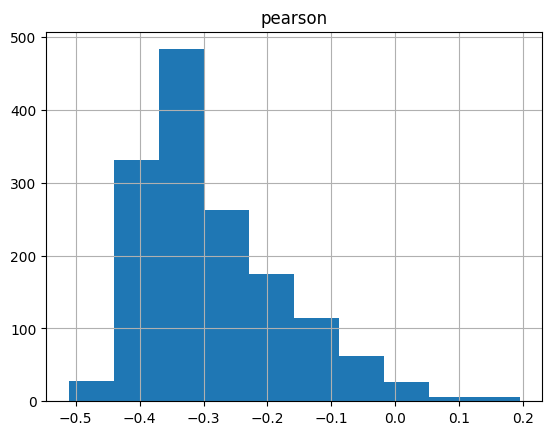

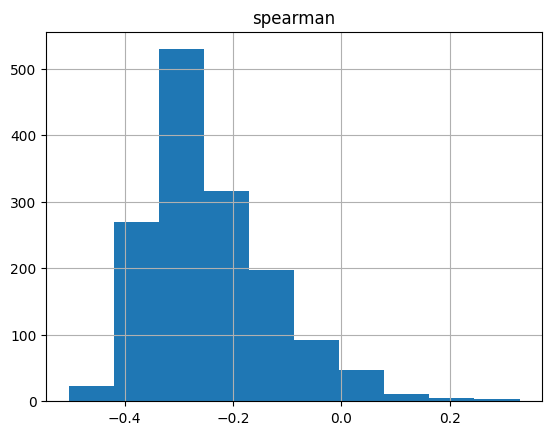

In [ ]:
corr_per_id.hist()
